In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

import seaborn as sns
from sklearn.decomposition import PCA

from sklearn.manifold import TSNE

FILE = '~/Documents/devlab/week1/Online_Retail.xlsx'

## Load & Clean Transaction Data

Clean the data. These are the steps.

Cleaning steps:
- Delete rows with a missing `CustomerID`
- Delete cancellations (`InvoiceNo` starting with `'C'`)
- Delete rows with [<=0] `Quantity`
- Delete rows where `Unit Price` is 0


In [2]:
df = pd.read_excel(FILE)


df = pd.read_excel(FILE)
current_count = len(df)
print(f"Initial dataset size: {current_count:,} rows")

df = df[df['CustomerID'].notna()]
removed = current_count - len(df)
current_count = len(df)
print(f"1. Removed {removed:,} rows with missing CustomerID -> {current_count:,} remaining")


df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
removed = current_count - len(df)
current_count = len(df)
print(f"2. Removed {removed:,} cancelled orders ('C') -> {current_count:,} remaining")


df = df[df['Quantity'] > 0]
removed = current_count - len(df)
current_count = len(df)
print(f"3. Removed {removed:,} rows with Quantity <= 0 -> {current_count:,} remaining")


df = df[df['UnitPrice'] > 0]
removed = current_count - len(df)
current_count = len(df)
print(f"4. Removed {removed:,} rows with UnitPrice <= 0 -> {current_count:,} remaining")

df_clean = df

Initial dataset size: 541,909 rows
1. Removed 135,080 rows with missing CustomerID -> 406,829 remaining
2. Removed 8,905 cancelled orders ('C') -> 397,924 remaining
3. Removed 0 rows with Quantity <= 0 -> 397,924 remaining
4. Removed 40 rows with UnitPrice <= 0 -> 397,884 remaining


## RFM Feature Engineering

For each customer we compute:
- **Recency** — days since their most recent purchase (relative to one day after the last date in the data)
- **Frequency** — number of distinct invoices (orders)
- **Monetary** — total amount spent

In [3]:

df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

df_clean['TotalSpend'] = df_clean['Quantity'] * df_clean['UnitPrice']

reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days, 
    'InvoiceNo': 'nunique',                                 
    'TotalSpend': 'sum'                                       
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print("=" * 50)
print(f"Reference Date Used: {reference_date}")
print(f"Total Unique Customers: {rfm['CustomerID'].nunique():,}")
print("=" * 50)

print("\n--- Summary Statistics (Mean, Std, Min, Max) ---")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().T[['mean', 'std', 'min', 'max']])

print("\n--- Percentile Distribution (Skewness Check) ---")
print(rfm[['Recency', 'Frequency', 'Monetary']].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

print("\n--- Top 5 Highest Spend Customers ---")
print(rfm.sort_values(by='Monetary', ascending=False).head())

Reference Date Used: 2011-12-10 12:50:00
Total Unique Customers: 4,338

--- Summary Statistics (Mean, Std, Min, Max) ---
                  mean          std   min        max
Recency      92.536422   100.014169  1.00     374.00
Frequency     4.272015     7.697998  1.00     209.00
Monetary   2054.266460  8989.230441  3.75  280206.02

--- Percentile Distribution (Skewness Check) ---
      Recency  Frequency    Monetary
0.25     18.0        1.0    307.4150
0.50     51.0        2.0    674.4850
0.75    142.0        5.0   1661.7400
0.90    263.0        9.0   3646.5310
0.95    312.0       13.0   5841.8430
0.99    369.0       30.0  19880.9957

--- Top 5 Highest Spend Customers ---
      CustomerID  Recency  Frequency   Monetary
1689     14646.0        2         73  280206.02
4201     18102.0        1         60  259657.30
3728     17450.0        8         46  194550.79
3008     16446.0        1          2  168472.50
1879     14911.0        1        201  143825.06


## Feature Preparation

RFM values are heavily right-skewed (a small number of customers order very
frequently / spend a lot), which would distort distance-based clustering.
We apply a `log1p` transform to reduce skew, then standardize the features
so Recency, Frequency, and Monetary contribute equally to distance calculations.


In [4]:
rfm_features = ['Recency', 'Frequency', 'Monetary']

print("--- Initial Skewness ---")
print(rfm[rfm_features].skew())

rfm_log = rfm[rfm_features].apply(np.log1p)

print("\n--- Skewness After log1p ---")
print(rfm_log.skew())

scaler = StandardScaler()
rfm_scaled_array = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(
    rfm_scaled_array, 
    columns=['Recency_Scaled', 'Frequency_Scaled', 'Monetary_Scaled'],
    index=rfm.index
)

rfm_prepared = pd.concat([rfm[['CustomerID']], rfm_scaled], axis=1)

print("\n--- Scaled Features Summary ---")
print(rfm_scaled.describe().round(3).T[['mean', 'std', 'min', '50%', 'max']])

--- Initial Skewness ---
Recency       1.246048
Frequency    12.067031
Monetary     19.324953
dtype: float64

--- Skewness After log1p ---
Recency     -0.379169
Frequency    1.208652
Monetary     0.393553
dtype: float64

--- Scaled Features Summary ---
                  mean  std    min    50%    max
Recency_Scaled    -0.0  1.0 -2.341  0.090  1.564
Frequency_Scaled  -0.0  1.0 -0.955 -0.362  5.859
Monetary_Scaled    0.0  1.0 -4.005 -0.062  4.732


## Clustering — K-Means

I wanted to use YellowBrick but couldnt because 'distutils' isnt supported on legacy Python version.
And overheads were too complicated so for this time I will go with standard scikitlearn

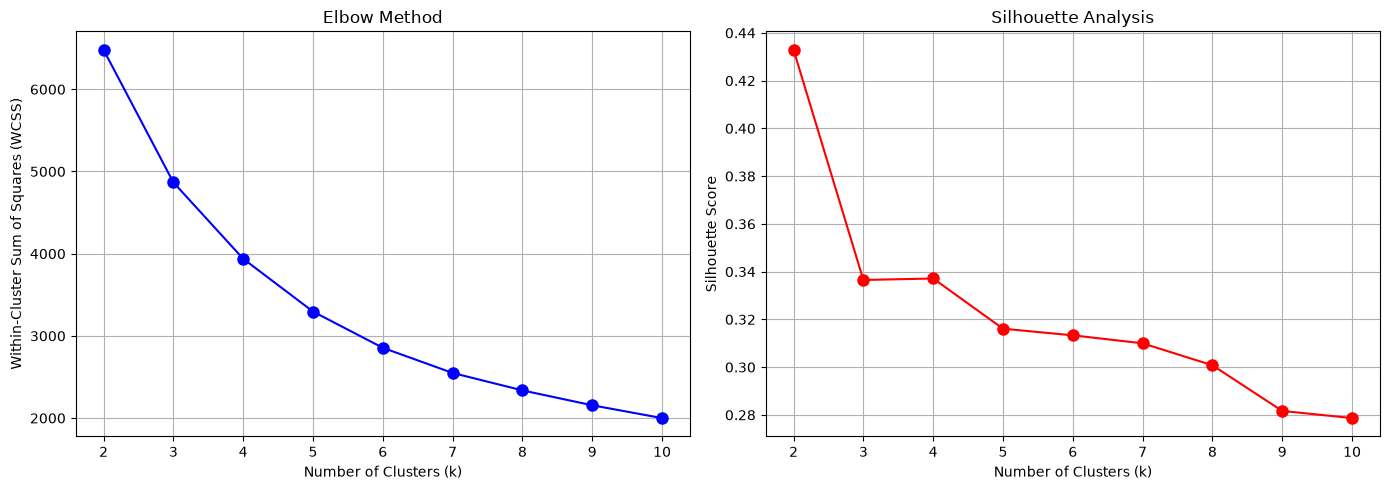

In [5]:
k_range = range(2, 11)
wcss = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, wcss, 'bo-', markersize=8)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Within-Cluster Sum of Squares (WCSS)')
ax1.set_title('Elbow Method')
ax1.grid(True)

ax2.plot(k_range, silhouette_scores, 'ro-', markersize=8)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.grid(True)

plt.tight_layout()
plt.show()

## Clustering — Hierarchial

We will do this using Dendrograms.

Applied 3 metric systems to tell how packed and far apart the clusters are.

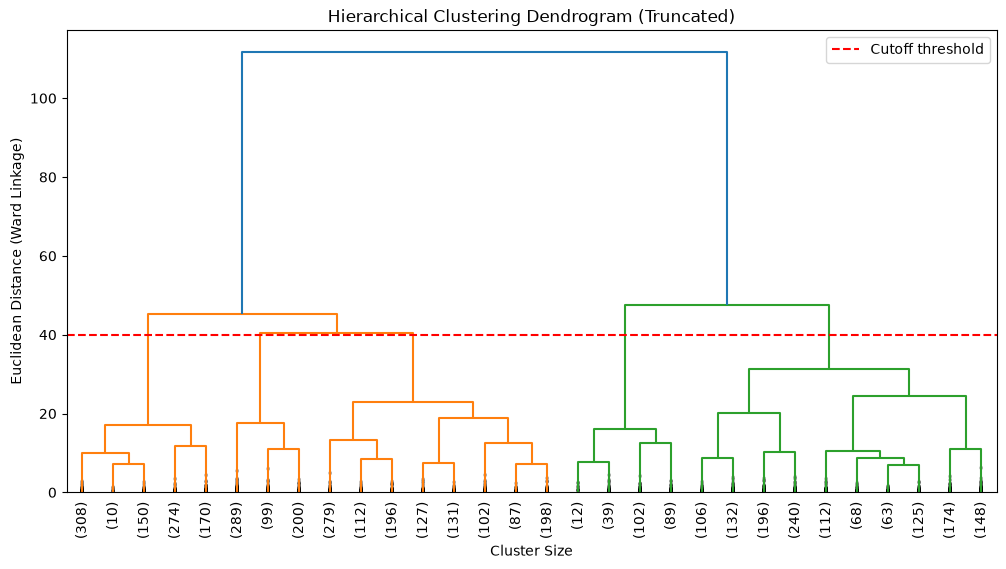

--- Hierarchical Clustering Results (k=4) ---
Silhouette Score (Higher is better): 0.242
Davies-Bouldin Index (Lower is better): 1.120
Calinski-Harabasz Index (Higher is better): 2615.1


In [6]:
linkage_matrix = linkage(rfm_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,             
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title("Hierarchical Clustering Dendrogram (Truncated)")
plt.xlabel("Cluster Size")
plt.ylabel("Euclidean Distance (Ward Linkage)")
plt.axhline(y=40, color='r', linestyle='--', label='Cutoff threshold')
plt.legend()
plt.show()

k_target = 4
hierarchical = AgglomerativeClustering(
    n_clusters=k_target, 
    metric='euclidean', 
    linkage='ward'
)
hierarchical_labels = hierarchical.fit_predict(rfm_scaled)

rfm['Hierarchical_Cluster'] = hierarchical_labels

sil_h = silhouette_score(rfm_scaled, hierarchical_labels)
db_h = davies_bouldin_score(rfm_scaled, hierarchical_labels)
ch_h = calinski_harabasz_score(rfm_scaled, hierarchical_labels)

print(f"--- Hierarchical Clustering Results (k={k_target}) ---")
print(f"Silhouette Score (Higher is better): {sil_h:.3f}")
print(f"Davies-Bouldin Index (Lower is better): {db_h:.3f}")
print(f"Calinski-Harabasz Index (Higher is better): {ch_h:.1f}")

## Clustering — DBSCAN

Took minimum samples as 6 and eps as 5

- Min Samples is 2 x 3(R,F,M) which equals 6
- Because stdev = 1, eps = 5

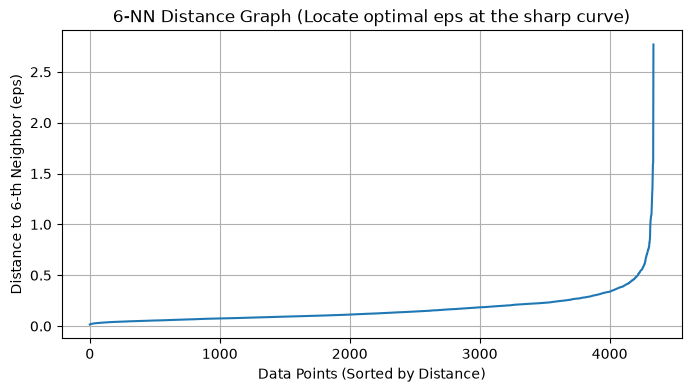

In [7]:
min_samples = 6

nn = NearestNeighbors(n_neighbors=min_samples)
nn_fit = nn.fit(rfm_scaled)
distances, _ = nn_fit.kneighbors(rfm_scaled)

distances = np.sort(distances[:, min_samples - 1], axis=0)

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title(f"{min_samples}-NN Distance Graph (Locate optimal eps at the sharp curve)")
plt.xlabel("Data Points (Sorted by Distance)")
plt.ylabel(f"Distance to {min_samples}-th Neighbor (eps)")
plt.grid(True)
plt.show()

In [8]:
eps_target = 0.5  

dbscan = DBSCAN(eps=eps_target, min_samples=min_samples)
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

db_labels = rfm['DBSCAN_Cluster']
mask = db_labels != -1 
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print(f"--- DBSCAN Results (eps={eps_target}, min_samples={min_samples}) ---")
print(f"Clusters Discovered: {n_clusters}")
print(f"Noise Points: {n_noise} ({n_noise / len(rfm):.2%} of dataset)")

if n_clusters > 1:
    sil_db = silhouette_score(rfm_scaled[mask], db_labels[mask])
    db_db = davies_bouldin_score(rfm_scaled[mask], db_labels[mask])
    ch_db = calinski_harabasz_score(rfm_scaled[mask], db_labels[mask])
    
    print(f"Silhouette Score (excl. noise): {sil_db:.3f}")
    print(f"Davies-Bouldin Index (excl. noise): {db_db:.3f}")
    print(f"Calinski-Harabasz Index (excl. noise): {ch_db:.1f}")
else:
    print("DBSCAN identified less than 2 valid clusters. Try adjusting eps or min_samples.")

--- DBSCAN Results (eps=0.5, min_samples=6) ---
Clusters Discovered: 4
Noise Points: 64 (1.48% of dataset)
Silhouette Score (excl. noise): 0.217
Davies-Bouldin Index (excl. noise): 0.857
Calinski-Harabasz Index (excl. noise): 1204.1


## Choosing the clustering algo and number of clusters

I choose K-Means because it performed best in most metrics

These are the best performers in different metrics:
- Silhouette: K-Means
- Davies-Bouldin: DBSCAN
- Calinski-Harabasz: K-Means

Also, K=4 because of Silhouette Score.

## Visualization (PCA)

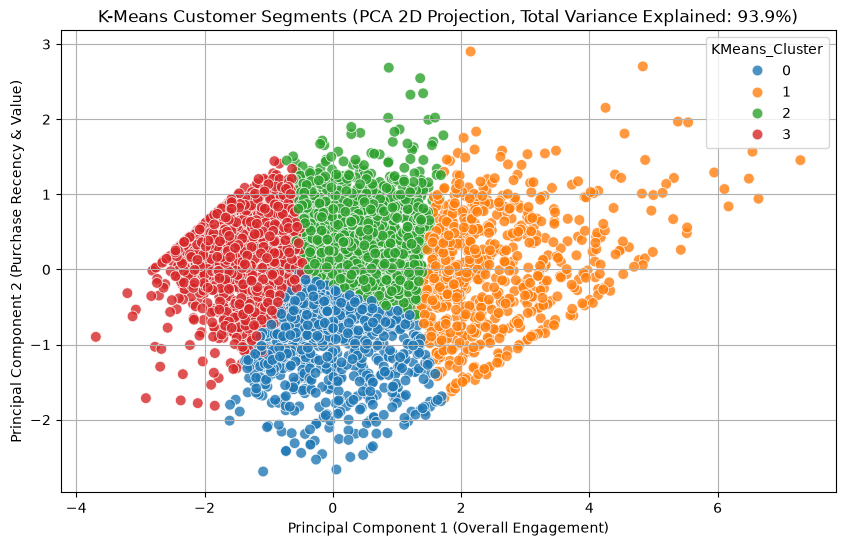

,Recency_Median,Recency_Mean,Frequency_Median,Frequency_Mean,Monetary_Median,Monetary_Mean,Customer_Count,Customer_Share_%
KMeans_Cluster,,,,,,,,
1,8.0,12.1,10.0,13.7,3733.9,8074.3,716,16.5
2,56.0,71.1,4.0,4.1,1345.6,1802.8,1173,27.0
0,17.0,18.1,2.0,2.1,471.7,551.8,837,19.3
3,177.0,182.5,1.0,1.3,298.3,343.5,1612,37.2


In [9]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['KMeans_Cluster'] = kmeans.fit_predict(rfm_scaled)

pca = PCA(n_components=2)
pca_features = pca.fit_transform(rfm_scaled)

rfm['PCA1'] = pca_features[:, 0]
rfm['PCA2'] = pca_features[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PCA1', 
    y='PCA2', 
    hue='KMeans_Cluster', 
    palette='tab10', 
    data=rfm, 
    alpha=0.8, 
    s=60
)
var_explained = sum(pca.explained_variance_ratio_) * 100
plt.title(f'K-Means Customer Segments (PCA 2D Projection, Total Variance Explained: {var_explained:.1f}%)')
plt.xlabel('Principal Component 1 (Overall Engagement)')
plt.ylabel('Principal Component 2 (Purchase Recency & Value)')
plt.grid(True)
plt.show()

cluster_profile = rfm.groupby('KMeans_Cluster').agg({
    'Recency': ['median', 'mean'],
    'Frequency': ['median', 'mean'],
    'Monetary': ['median', 'mean', 'count']
}).round(1)

cluster_profile.columns = [
    'Recency_Median', 'Recency_Mean',
    'Frequency_Median', 'Frequency_Mean',
    'Monetary_Median', 'Monetary_Mean', 'Customer_Count'
]
cluster_profile['Customer_Share_%'] = round(cluster_profile['Customer_Count'] / len(rfm) * 100, 1)

cluster_profile.sort_values(by='Monetary_Median', ascending=False)

## Explanation

So each section is one category of customers:

1. Absolute best-buyers
2. Loyals
3. Normal shoppers that buy sometimes
4. One-timers

## BONUS

Applied t-SNE for better visualization.

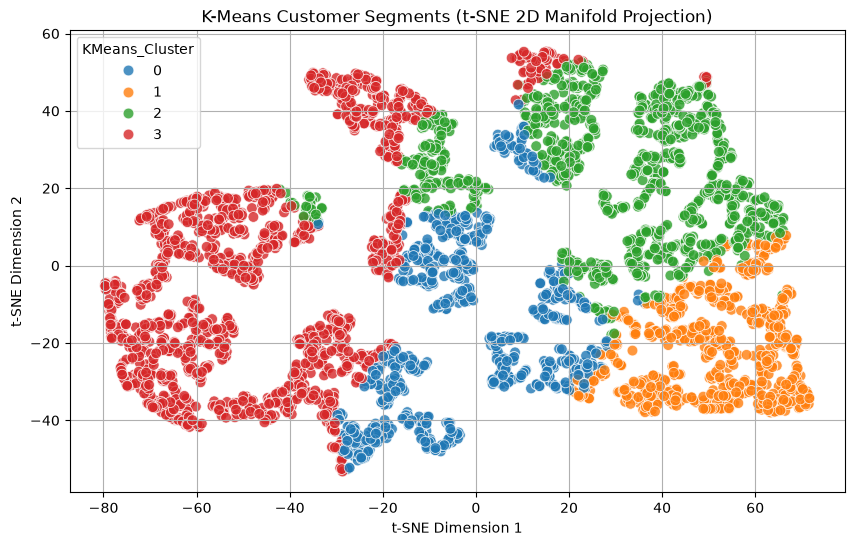

In [10]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_results = tsne.fit_transform(rfm_scaled)

rfm['TSNE1'] = tsne_results[:, 0]
rfm['TSNE2'] = tsne_results[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='TSNE1', 
    y='TSNE2', 
    hue='KMeans_Cluster', 
    palette='tab10', 
    data=rfm, 
    alpha=0.8, 
    s=60
)
plt.title('K-Means Customer Segments (t-SNE 2D Manifold Projection)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True)
plt.show()